In [1]:
import sys
print(sys.executable)
print(sys.prefix)

c:\Users\shibu\AppData\Local\Programs\Python\Python314\python.exe
c:\Users\shibu\AppData\Local\Programs\Python\Python314


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [3]:
df = pd.read_csv('GDSC_dataset.csv')
df2 = pd.read_csv('model_list_latest.csv')
gf = pd.read_csv('genomic_features.csv', low_memory=False)

In [4]:
'''
gf = pd.read_csv('genomic_features.csv', low_memory=False)

print(f"Shape             : {gf.shape}")
print(f"Unique cell lines : {gf['COSMIC ID'].nunique()}")
print(f"Unique features   : {gf['Genetic Feature'].nunique()}")
print(f"\nIS Mutated values:")
print(gf['IS Mutated'].value_counts(dropna=False).to_string())
print(f"\nFeature type sample (first 20):")
print(gf['Genetic Feature'].head(20).tolist())
print(f"\nFeature type sample (last 20):")
print(gf['Genetic Feature'].tail(20).tolist())

# Check how many are _mut vs CNA
mut_features = gf[gf['Genetic Feature'].str.endswith('_mut')]['Genetic Feature'].nunique()
cna_features = gf[~gf['Genetic Feature'].str.endswith('_mut')]['Genetic Feature'].nunique()
print(f"\nMutation features (_mut) : {mut_features:,}")
print(f"CNA features             : {cna_features:,}") '''


'\ngf = pd.read_csv(\'genomic_features.csv\', low_memory=False)\n\nprint(f"Shape             : {gf.shape}")\nprint(f"Unique cell lines : {gf[\'COSMIC ID\'].nunique()}")\nprint(f"Unique features   : {gf[\'Genetic Feature\'].nunique()}")\nprint(f"\nIS Mutated values:")\nprint(gf[\'IS Mutated\'].value_counts(dropna=False).to_string())\nprint(f"\nFeature type sample (first 20):")\nprint(gf[\'Genetic Feature\'].head(20).tolist())\nprint(f"\nFeature type sample (last 20):")\nprint(gf[\'Genetic Feature\'].tail(20).tolist())\n\n# Check how many are _mut vs CNA\nmut_features = gf[gf[\'Genetic Feature\'].str.endswith(\'_mut\')][\'Genetic Feature\'].nunique()\ncna_features = gf[~gf[\'Genetic Feature\'].str.endswith(\'_mut\')][\'Genetic Feature\'].nunique()\nprint(f"\nMutation features (_mut) : {mut_features:,}")\nprint(f"CNA features             : {cna_features:,}") '

In [5]:
print(f"df Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"df2 Loaded: {df2.shape[0]:,} rows × {df2.shape[1]} columns")
print(f"gf Loaded: {gf.shape[0]:,} rows × {gf.shape[1]} columns")

df Loaded: 242,035 rows × 19 columns
df2 Loaded: 2,266 rows × 96 columns
gf Loaded: 698,000 rows × 9 columns


In [6]:
print("All columns in dataset:")
for i, col in enumerate(df.columns.tolist()):
    print(f"  [{i:02d}] '{col}'")

All columns in dataset:
  [00] 'COSMIC_ID'
  [01] 'CELL_LINE_NAME'
  [02] 'TCGA_DESC'
  [03] 'DRUG_ID'
  [04] 'DRUG_NAME'
  [05] 'LN_IC50'
  [06] 'AUC'
  [07] 'Z_SCORE'
  [08] 'GDSC Tissue descriptor 1'
  [09] 'GDSC Tissue descriptor 2'
  [10] 'Cancer Type (matching TCGA label)'
  [11] 'Microsatellite instability Status (MSI)'
  [12] 'Screen Medium'
  [13] 'Growth Properties'
  [14] 'CNA'
  [15] 'Gene Expression'
  [16] 'Methylation'
  [17] 'TARGET'
  [18] 'TARGET_PATHWAY'


In [7]:
# dropping unnecessary columns
LEAKAGE_COLS = [
    'AUC', 'Z_SCORE',      #      direct leakage — summaries of LN_IC50 
    ]

 # Only drop columns that actually exist in this file (guards against version differences)
cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

In [8]:
print(f"Remaining shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Remaining shape: 242,035 rows × 17 columns


HIGH PRIORITY

In [9]:
 # Checking if the TCGA cancer type is the same 'cancer type' column

CANCER_TYPE_COL = 'Cancer Type (matching TCGA label)'   #  exact column name

if CANCER_TYPE_COL in df.columns:
    df[CANCER_TYPE_COL] = df[CANCER_TYPE_COL].replace({
        'COAD/READ'          : 'COREAD',         # harmonise to TCGA vocabulary
        'UNABLE TO CLASSIFY' : 'UNCLASSIFIED',   # harmonise to TCGA vocabulary
    })
    print(f"\Resolved label mismatches in '{CANCER_TYPE_COL}'")
    print(f"COAD/READ → COREAD, UNABLE TO CLASSIFY → UNCLASSIFIED")
else:
    print(f"\nStep 4 —# '{CANCER_TYPE_COL}' not found; skipped")

\Resolved label mismatches in 'Cancer Type (matching TCGA label)'
COAD/READ → COREAD, UNABLE TO CLASSIFY → UNCLASSIFIED


<>:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\shibu\AppData\Local\Temp\ipykernel_14620\177613408.py:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  print(f"\Resolved label mismatches in '{CANCER_TYPE_COL}'")


In [10]:

tcga_missing_before = df['TCGA_DESC'].isna().sum()

if CANCER_TYPE_COL in df.columns:

     # Flag rows where TCGA_DESC was originally missing (1 = will be/was filled)
    df['tcga_was_crossfilled'] = (
        df['TCGA_DESC'].isna() & df[CANCER_TYPE_COL].notna()
    ).astype(int)

    #  Fill TCGA_DESC gaps using Cancer Type (where Cancer Type has a value)
    df['TCGA_DESC'] = df['TCGA_DESC'].fillna(df[CANCER_TYPE_COL])

    tcga_missing_after = df['TCGA_DESC'].isna().sum()
    recovered = tcga_missing_before - tcga_missing_after

     # Drop Cancer Type — crossfill complete
    df.drop(columns=[CANCER_TYPE_COL], inplace=True)

    print(f"\nStep 5 — Crossfilled TCGA_DESC from Cancer Type")
    print(f"         Missing before : {tcga_missing_before:,}")
    print(f"         Recovered      : {recovered:,}")
    print(f"         Still missing  : {tcga_missing_after:,}  "
          f"(rows where both columns were blank)")
    print(f"         tcga_was_crossfilled=1 rows: {df['tcga_was_crossfilled'].sum():,}")
    print(f"         Cancer Type column dropped")

else:
    # Cancer Type column not available — still create the flag column (all zeros)
    df['tcga_was_crossfilled'] = 0
    print(f"\nStep 5 — Cancer Type not found; tcga_was_crossfilled set to 0")



Step 5 — Crossfilled TCGA_DESC from Cancer Type
         Missing before : 1,067
         Recovered      : 360
         Still missing  : 707  (rows where both columns were blank)
         tcga_was_crossfilled=1 rows: 360
         Cancer Type column dropped


In [11]:
still_missing_before = df['TCGA_DESC'].isna().sum()  # should be 707

mask_pass3 = df['TCGA_DESC'].isna() & df['GDSC Tissue descriptor 1'].notna()
df.loc[mask_pass3, 'TCGA_DESC'] = df.loc[mask_pass3, 'GDSC Tissue descriptor 1']

still_missing_after = df['TCGA_DESC'].isna().sum()
filled_pass3 = still_missing_before - still_missing_after

print(f"Step 5 (pass 3) — Fallback fill from Tissue descriptor 1")
print(f"         Filled  : {filled_pass3:,}")
print(f"         Still missing : {still_missing_after:,}")

Step 5 (pass 3) — Fallback fill from Tissue descriptor 1
         Filled  : 707
         Still missing : 0


In [12]:
# Cell-line-level remap (more precise than a broad label remap)
cell_line_remap = {
    'MHH-CALL-4' : 'ALL',
    'BONNA-12'   : 'UNCLASSIFIED',
    'U-CH2'      : 'UNCLASSIFIED',
    'NCCIT'      : 'UNCLASSIFIED',
}

for cell_line, new_label in cell_line_remap.items():
    mask = df['CELL_LINE_NAME'] == cell_line
    df.loc[mask, 'TCGA_DESC'] = new_label
    rows_updated = mask.sum()
    print(f"  {cell_line:<15} → {new_label:<15} ({rows_updated} rows updated)")

# Verify no broad tissue labels remain
remaining = df[df['TCGA_DESC'].isin(['leukemia', 'bone', 'urogenital_system'])]
print(f"\n  Broad tissue labels remaining : {len(remaining)}")
print(f"  TCGA_DESC unique values now   : {df['TCGA_DESC'].nunique()}")

  MHH-CALL-4      → ALL             (179 rows updated)
  BONNA-12        → UNCLASSIFIED    (179 rows updated)
  U-CH2           → UNCLASSIFIED    (179 rows updated)
  NCCIT           → UNCLASSIFIED    (170 rows updated)

  Broad tissue labels remaining : 0
  TCGA_DESC unique values now   : 32


In [13]:
# Remap all the OTHER from TCGA_DESC to Prostate, because all "OTHER" row represents "urogenital_system" :"prostate"
df['TCGA_DESC'] = df['TCGA_DESC'].replace({'OTHER': 'PRAD'})

print(f"OTHER remaining : {(df['TCGA_DESC'] == 'OTHER').sum()}")
print(f"PRAD rows now   : {(df['TCGA_DESC'] == 'PRAD').sum()}")

OTHER remaining : 0
PRAD rows now   : 1855


In [14]:
# Bulk remap all OTHER → PRAD first
df['TCGA_DESC'] = df['TCGA_DESC'].replace({'OTHER': 'PRAD'})

# Then immediately correct both prostate exceptions back to UNCLASSIFIED
exceptions = ['BPH-1', 'NCI-H660']
for cell_line in exceptions:
    mask = df['CELL_LINE_NAME'] == cell_line
    df.loc[mask, 'TCGA_DESC'] = 'UNCLASSIFIED'
    print(f"  {cell_line:<15} → UNCLASSIFIED  ({mask.sum()} rows corrected)")

print(f"\n  OTHER remaining   : {(df['TCGA_DESC'] == 'OTHER').sum()}")
print(f"  PRAD total rows   : {(df['TCGA_DESC'] == 'PRAD').sum()}")
print(f"  Unique TCGA values: {df['TCGA_DESC'].nunique()}")

  BPH-1           → UNCLASSIFIED  (279 rows corrected)
  NCI-H660        → UNCLASSIFIED  (179 rows corrected)

  OTHER remaining   : 0
  PRAD total rows   : 1676
  Unique TCGA values: 31


What we did here was that we first turned all the other into PRAD becuase there is pattern with "urogenital_system" :"prostate". PRAD is for adenocarcinoma, which not a lot of "urogenital_system" :"prostate" carries. 'BPH-1', 'NCI-H660' dont coform to this. So we are going to swap thso PRAD of these 2, into unclassified

With this, TCGA PREPROCESSING is done.

Started with  : 1,067 missing, 32 values (including non-TCGA labels)
Finished with : 0 missing, 31 clean TCGA labels ( we remapped other)

TCGA_DESC LABEL REFERENCE — 31 categories (final, post-preprocessing)

#################################################

 Label         - Definition                               ---               Rows
 
 UNCLASSIFIED — Cell line could not be mapped to any TCGA type  ---     46,397

 LUAD         — Lung Adenocarcinoma           ---                        15,653

 SCLC         — Small Cell Lung Cancer           ---                     13,750

 BRCA         — Breast Invasive Carcinoma           ---                  13,106

 COREAD       — Colon & Rectum Adenocarcinoma (merged TCGA cohort)  ---  12,718

 SKCM         — Skin Cutaneous Melanoma                 ---              12,637

 HNSC         — Head and Neck Squamous Cell Carcinoma      ---            9,358

 ESCA         — Esophageal Carcinoma                          ---         9,126

 GBM          — Glioblastoma Multiforme                          ---      8,384

 OV           — Ovarian Serous Cystadenocarcinoma                   ---   8,166

 DLBC         — Diffuse Large B-cell Lymphoma        ---                  7,978

 PAAD         — Pancreatic Adenocarcinoma               ---               7,513

 NB           — Neuroblastoma                 ---                         7,469

 KIRC         — Kidney Renal Clear Cell Carcinoma    ---                      7,462

 ALL          — Acute Lymphoblastic Leukemia            ---               6,974

 LAML         — Acute Myeloid Leukemia                     ---            6,209

 STAD         — Stomach Adenocarcinoma                        ---         6,060

 MESO         — Mesothelioma             ---                              5,561

 BLCA         — Bladder Urothelial Carcinoma   ---                        4,724

 MM           — Multiple Myeloma                  ---                     4,598

 LIHC         — Liver Hepatocellular Carcinoma       ---                  4,164

 THCA         — Thyroid Carcinoma                       ---               4,037

 LUSC         — Lung Squamous Cell Carcinoma        ---                   3,863

 CESC         — Cervical Squamous Cell & Endocervical Adenocarcinoma ---  3,811

 LGG          — Brain Lower Grade Glioma        ---                       3,617

 LCML         — Chronic Myelogenous Leukemia       ---                    2,611

 UCEC         — Uterine Corpus Endometrial Carcinoma  ---                 2,512

 PRAD         — Prostate Adenocarcinoma                  ---              1,676

 MB           — Medulloblastoma                             ---           1,072

 CLL          — Chronic Lymphocytic Leukemia                   ---          550

 ACC          — Adrenocortical Carcinoma             ---                    279

 ─────────────────────────────────────────────────────────────────────────
 Total rows   : 242,035


 Notes:
   - UNCLASSIFIED is a valid biological label, not missing data (19.2%)
   - OTHER (32nd label) removed — rows remapped to PRAD or UNCLASSIFIED
   - BPH-1    → UNCLASSIFIED  (Benign Prostatic Hyperplasia, non-cancerous)
   - NCI-H660 → UNCLASSIFIED  (Neuroendocrine Prostate Carcinoma, not adenocarcinoma)
   - MHH-CALL-4 → ALL         (B-cell Acute Lymphoblastic Leukaemia, confirmed)
   - BONNA-12, U-CH2, NCCIT → UNCLASSIFIED (no direct TCGA equivalent)
   - Source: TCGA official definitions + Cell Lines Details decode sheet

In [15]:
# This is for printing out the changed dataset
'''

checkpoint_cols = [
    'COSMIC_ID',
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'tcga_was_crossfilled',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
]

df[checkpoint_cols].to_csv('tcga_checkpoint.csv', index=False)

print("Saved: tcga_checkpoint.csv")
print(f"Rows: {len(df):,}")
print(f"\nValue counts for TCGA_DESC:")
print(df['TCGA_DESC'].value_counts(dropna=False).to_string())
print(f"\nCrossfilled rows (tcga_was_crossfilled=1): {df['tcga_was_crossfilled'].sum():,}")    
'''

'\n\ncheckpoint_cols = [\n    \'COSMIC_ID\',\n    \'CELL_LINE_NAME\',\n    \'TCGA_DESC\',\n    \'tcga_was_crossfilled\',\n    \'GDSC Tissue descriptor 1\',\n    \'GDSC Tissue descriptor 2\',\n]\n\ndf[checkpoint_cols].to_csv(\'tcga_checkpoint.csv\', index=False)\n\nprint("Saved: tcga_checkpoint.csv")\nprint(f"Rows: {len(df):,}")\nprint(f"\nValue counts for TCGA_DESC:")\nprint(df[\'TCGA_DESC\'].value_counts(dropna=False).to_string())\nprint(f"\nCrossfilled rows (tcga_was_crossfilled=1): {df[\'tcga_was_crossfilled\'].sum():,}")    \n'

Tissue Descriptor 1 & 2 Fix
- We will first merge this file (acquired from the website of sanger/cosmic, the same place as the dataset orign) and then use it's contents to fill the tissue descriptor 1 and 2.

In [16]:
# Column mapping:
#   Passports 'tissue'             → GDSC Tissue descriptor 1  (broader label)
#   Passports 'cancer_type_detail' → GDSC Tissue descriptor 2  (finer subtype)

DESC1_COL = 'GDSC Tissue descriptor 1'
DESC2_COL = 'GDSC Tissue descriptor 2'

# ── Normalise COSMIC_ID to string in both datasets ────────────────────────
df['COSMIC_ID']  = df['COSMIC_ID'].astype(str).str.strip()
df2['COSMIC_ID'] = df2['COSMIC_ID'].astype(str).str.strip()

# ── Record missing counts BEFORE any filling ──────────────────────────────
desc1_missing_before = df[DESC1_COL].isna().sum()
desc2_missing_before = df[DESC2_COL].isna().sum()

print(f"Before fill:")
print(f"  Descriptor 1 missing : {desc1_missing_before:,}")
print(f"  Descriptor 2 missing : {desc2_missing_before:,}")

Before fill:
  Descriptor 1 missing : 9,366
  Descriptor 2 missing : 9,366


In [17]:
# ── Set imputation flags BEFORE any filling ───────────────────────────────
df['descriptor1_was_imputed'] = df[DESC1_COL].isna().astype(int)
df['descriptor2_was_imputed'] = df[DESC2_COL].isna().astype(int)

# ── Coverage check ────────────────────────────────────────────────────────
missing_d1_ids = set(df[df[DESC1_COL].isna()]['COSMIC_ID'].unique())
missing_d2_ids = set(df[df[DESC2_COL].isna()]['COSMIC_ID'].unique())
passport_ids   = set(df2['COSMIC_ID'].unique())

print(f"\nCoverage check:")
print(f"  Descriptor 1 — unique cell lines missing : {len(missing_d1_ids):,}")
print(f"                 covered by Passports      : {len(missing_d1_ids & passport_ids):,}")
print(f"                 not found in Passports    : {len(missing_d1_ids - passport_ids):,}")
print(f"  Descriptor 2 — unique cell lines missing : {len(missing_d2_ids):,}")
print(f"                 covered by Passports      : {len(missing_d2_ids & passport_ids):,}")
print(f"                 not found in Passports    : {len(missing_d2_ids - passport_ids):,}")



Coverage check:
  Descriptor 1 — unique cell lines missing : 39
                 covered by Passports      : 39
                 not found in Passports    : 0
  Descriptor 2 — unique cell lines missing : 39
                 covered by Passports      : 39
                 not found in Passports    : 0


In [18]:
df2_clean = df2[df2['COSMIC_ID'] != 'nan'].copy()

print(f"df2 rows with valid COSMIC_ID : {len(df2_clean):,}")
print(f"df2 rows dropped (no COSMIC_ID): {len(df2) - len(df2_clean):,}")

# ── Build clean lookup — one row per COSMIC_ID ────────────────────────────
passport_lookup = (
    df2_clean[['COSMIC_ID', 'tissue', 'cancer_type_detail']]
    .drop_duplicates(subset='COSMIC_ID', keep='first')
)

print(f"passport_lookup shape         : {passport_lookup.shape}")

df2 rows with valid COSMIC_ID : 2,266
df2 rows dropped (no COSMIC_ID): 0
passport_lookup shape         : (1125, 3)


In [19]:
# ── Merge Passports into df ───────────────────────────────────────────────
df = df.merge(passport_lookup, on='COSMIC_ID', how='left')

# ── Fill Descriptor 1 from Passports 'tissue' ────────────────────────────
mask_d1 = df[DESC1_COL].isna() & df['tissue'].notna()
df.loc[mask_d1, DESC1_COL] = df.loc[mask_d1, 'tissue']

# ── Fill Descriptor 2 from Passports 'cancer_type_detail' ────────────────
mask_d2 = df[DESC2_COL].isna() & df['cancer_type_detail'].notna()
df.loc[mask_d2, DESC2_COL] = df.loc[mask_d2, 'cancer_type_detail']

# ── Drop temporary passport columns ───────────────────────────────────────
df.drop(columns=['tissue', 'cancer_type_detail'], inplace=True)

desc1_after_passport = df[DESC1_COL].isna().sum()
desc2_after_passport = df[DESC2_COL].isna().sum()

print(f"\nAfter Passports join:")
print(f"  Descriptor 1 missing : {desc1_after_passport:,}")
print(f"  Descriptor 2 missing : {desc2_after_passport:,}")


After Passports join:
  Descriptor 1 missing : 0
  Descriptor 2 missing : 0


In [20]:
# ── Final verification ────────────────────────────────────────────────────
print(f"Final state:")
print(f"  Descriptor 1 missing          : {df[DESC1_COL].isna().sum()}")
print(f"  Descriptor 2 missing          : {df[DESC2_COL].isna().sum()}")
print(f"  Descriptor 1 unique values    : {df[DESC1_COL].nunique()}")
print(f"  Descriptor 2 unique values    : {df[DESC2_COL].nunique()}")
print(f"  descriptor1_was_imputed=1     : {df['descriptor1_was_imputed'].sum():,}")
print(f"  descriptor2_was_imputed=1     : {df['descriptor2_was_imputed'].sum():,}")
print(f"  df shape                      : {df.shape}")

Final state:
  Descriptor 1 missing          : 0
  Descriptor 2 missing          : 0
  Descriptor 1 unique values    : 34
  Descriptor 2 unique values    : 78
  descriptor1_was_imputed=1     : 9,366
  descriptor2_was_imputed=1     : 9,366
  df shape                      : (242035, 19)


In [21]:
'''
checkpoint_cols = [
    'COSMIC_ID',
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'descriptor1_was_imputed',
    'descriptor2_was_imputed',
]

df[checkpoint_cols].to_csv('descriptor_checkpoint.csv', index=False)

print("Saved: descriptor_checkpoint.csv")
print(f"Rows : {len(df):,}")
print(f"\nDescriptor 2 value counts:")
print(df[DESC2_COL].value_counts(dropna=False).to_string())
print(f"\nStill missing: {df[DESC2_COL].isna().sum()}") '''

'\ncheckpoint_cols = [\n    \'COSMIC_ID\',\n    \'CELL_LINE_NAME\',\n    \'TCGA_DESC\',\n    \'GDSC Tissue descriptor 1\',\n    \'GDSC Tissue descriptor 2\',\n    \'descriptor1_was_imputed\',\n    \'descriptor2_was_imputed\',\n]\n\ndf[checkpoint_cols].to_csv(\'descriptor_checkpoint.csv\', index=False)\n\nprint("Saved: descriptor_checkpoint.csv")\nprint(f"Rows : {len(df):,}")\nprint(f"\nDescriptor 2 value counts:")\nprint(df[DESC2_COL].value_counts(dropna=False).to_string())\nprint(f"\nStill missing: {df[DESC2_COL].isna().sum()}") '

FILL MSI, SCREEN MEDIUM, GROWTH PROPERTIES WITH "Unknown"

- All three share the same 9,366 missing bloc. MSI has additional missingness beyond that — 12,353 rows total (5.1%).
- No reliable source column to crossfill from — filling with "Unknown" creates an explicit learnable category rather than leaving invisible nulls.
- A null becomes all-zeros after encoding (ambiguous).
- "Unknown" gets its own binary column after encoding (explicit signal).

In [22]:
FILL_UNKNOWN_COLS = [
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
]

for col in FILL_UNKNOWN_COLS:
    missing_count = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"  {col}")
    print(f"    Filled        : {missing_count:,} nulls → 'Unknown'")
    print(f"    Categories now: {sorted(df[col].unique().tolist())}")
    print()

print("Post-fill missing check:")
for col in FILL_UNKNOWN_COLS:
    print(f"  {col:<45} missing: {df[col].isna().sum()}")

  Microsatellite instability Status (MSI)
    Filled        : 12,353 nulls → 'Unknown'
    Categories now: ['MSI-H', 'MSS/MSI-L', 'Unknown']

  Screen Medium
    Filled        : 9,366 nulls → 'Unknown'
    Categories now: ['D/F12', 'R', 'Unknown']

  Growth Properties
    Filled        : 9,366 nulls → 'Unknown'
    Categories now: ['Adherent', 'Semi-Adherent', 'Suspension', 'Unknown']

Post-fill missing check:
  Microsatellite instability Status (MSI)       missing: 0
  Screen Medium                                 missing: 0
  Growth Properties                             missing: 0


In [23]:
# ── Can Passports improve on "Unknown" fills? ─────────────────────────────

print("Passports msi_status sample:")
print(df2_clean['msi_status'].value_counts(dropna=False).to_string())
print()
print("Passports growth_properties sample:")
print(df2_clean['growth_properties'].value_counts(dropna=False).to_string())
print()

# How many of our Unknown MSI rows are covered by Passports?
unknown_msi_ids = set(
    df[df['Microsatellite instability Status (MSI)'] == 'Unknown']['COSMIC_ID'].unique()
)
unknown_growth_ids = set(
    df[df['Growth Properties'] == 'Unknown']['COSMIC_ID'].unique()
)
passport_ids = set(df2_clean['COSMIC_ID'].unique())

print(f"Unknown MSI rows    — unique cell lines : {len(unknown_msi_ids):,}")
print(f"                      covered by Passports: {len(unknown_msi_ids & passport_ids):,}")
print(f"                      not found          : {len(unknown_msi_ids - passport_ids):,}")
print()
print(f"Unknown Growth rows — unique cell lines : {len(unknown_growth_ids):,}")
print(f"                      covered by Passports: {len(unknown_growth_ids & passport_ids):,}")
print(f"                      not found          : {len(unknown_growth_ids - passport_ids):,}")

Passports msi_status sample:
msi_status
MSS    1097
NaN    1076
MSI      93

Passports growth_properties sample:
growth_properties
Adherent         1064
Unknown           726
Suspension        416
Semi-Adherent      60

Unknown MSI rows    — unique cell lines : 53
                      covered by Passports: 53
                      not found          : 0

Unknown Growth rows — unique cell lines : 39
                      covered by Passports: 39
                      not found          : 0


In [24]:
# MSI — what values would the 53 unknown cell lines get?
unknown_msi_rows = df2_clean[df2_clean['COSMIC_ID'].isin(unknown_msi_ids)]
print("MSI — Passports values for our Unknown cell lines:")
print(unknown_msi_rows['msi_status'].value_counts(dropna=False).to_string())
print()

# Growth — what values would the 39 unknown cell lines get?
unknown_growth_rows = df2_clean[df2_clean['COSMIC_ID'].isin(unknown_growth_ids)]
print("Growth — Passports values for our Unknown cell lines:")
print(unknown_growth_rows['growth_properties'].value_counts(dropna=False).to_string())
print()

# Check label format difference for MSI
print("Your df MSI categories    :", sorted(df['Microsatellite instability Status (MSI)'].unique()))
print("Passports msi_status cats :", sorted(df2_clean['msi_status'].dropna().unique()))

MSI — Passports values for our Unknown cell lines:
msi_status
MSS    49
NaN     3
MSI     1

Growth — Passports values for our Unknown cell lines:
growth_properties
Unknown       18
Adherent      16
Suspension     5

Your df MSI categories    : ['MSI-H', 'MSS/MSI-L', 'Unknown']
Passports msi_status cats : ['MSI', 'MSS']


In [25]:
# Step 7 filled all nulls with "Unknown" as a safe placeholder.
# Step 7b replaces "Unknown" with real Sanger values where available.
#
# MSI label mapping (Passports → your df vocabulary):
#   MSS → MSS/MSI-L
#   MSI → MSI-H
#
# Growth Properties — Passports uses same labels (Adherent, Suspension etc.)
# so no remapping needed. Passports "Unknown" rows stay as Unknown.
# ─────────────────────────────────────────────────────────────────────────────

MSI_COL    = 'Microsatellite instability Status (MSI)'
GROWTH_COL = 'Growth Properties'

# ── Build MSI lookup from Passports ──────────────────────────────────────
# Remap Passports labels to match your df vocabulary
msi_label_map = {
    'MSS' : 'MSS/MSI-L',
    'MSI' : 'MSI-H',
}

msi_lookup = (
    df2_clean[['COSMIC_ID', 'msi_status']]
    .dropna(subset=['msi_status'])
    .drop_duplicates(subset='COSMIC_ID', keep='first')
    .copy()
)
msi_lookup['msi_status'] = msi_lookup['msi_status'].map(msi_label_map)

# ── Build Growth lookup from Passports ───────────────────────────────────
growth_lookup = (
    df2_clean[['COSMIC_ID', 'growth_properties']]
    .dropna(subset=['growth_properties'])
    .query("growth_properties != 'Unknown'")   # skip Passports unknowns
    .drop_duplicates(subset='COSMIC_ID', keep='first')
)

# ── Upgrade MSI Unknown rows ──────────────────────────────────────────────
msi_before = (df[MSI_COL] == 'Unknown').sum()

df = df.merge(msi_lookup, on='COSMIC_ID', how='left')
mask_msi = (df[MSI_COL] == 'Unknown') & df['msi_status'].notna()
df.loc[mask_msi, MSI_COL] = df.loc[mask_msi, 'msi_status']
df.drop(columns=['msi_status'], inplace=True)

msi_after = (df[MSI_COL] == 'Unknown').sum()
print(f"MSI upgrade:")
print(f"  Unknown before : {msi_before:,}")
print(f"  Upgraded       : {msi_before - msi_after:,}")
print(f"  Still Unknown  : {msi_after:,}  (Passports also has no data)")
print(f"  Categories now : {sorted(df[MSI_COL].unique().tolist())}")
print()

MSI upgrade:
  Unknown before : 12,353
  Upgraded       : 11,723
  Still Unknown  : 630  (Passports also has no data)
  Categories now : ['MSI-H', 'MSS/MSI-L', 'Unknown']



In [26]:
# ── Upgrade Growth Properties Unknown rows ────────────────────────────────
growth_before = (df[GROWTH_COL] == 'Unknown').sum()

df = df.merge(growth_lookup, on='COSMIC_ID', how='left')
mask_growth = (df[GROWTH_COL] == 'Unknown') & df['growth_properties'].notna()
df.loc[mask_growth, GROWTH_COL] = df.loc[mask_growth, 'growth_properties']
df.drop(columns=['growth_properties'], inplace=True)

growth_after = (df[GROWTH_COL] == 'Unknown').sum()
print(f"Growth Properties upgrade:")
print(f"  Unknown before : {growth_before:,}")
print(f"  Upgraded       : {growth_before - growth_after:,}")
print(f"  Still Unknown  : {growth_after:,}  (Passports also has no data)")
print(f"  Categories now : {sorted(df[GROWTH_COL].unique().tolist())}")
print()

# ── Final verification ────────────────────────────────────────────────────
print(f"Post Step 7b missing check:")
print(f"  {MSI_COL:<45} missing: {df[MSI_COL].isna().sum()}")
print(f"  {GROWTH_COL:<45} missing: {df[GROWTH_COL].isna().sum()}")
print(f"  df shape : {df.shape}")

Growth Properties upgrade:
  Unknown before : 9,366
  Upgraded       : 4,644
  Still Unknown  : 4,722  (Passports also has no data)
  Categories now : ['Adherent', 'Semi-Adherent', 'Suspension', 'Unknown']

Post Step 7b missing check:
  Microsatellite instability Status (MSI)       missing: 0
  Growth Properties                             missing: 0
  df shape : (242035, 19)


In [27]:
'''
checkpoint_cols = [
    'COSMIC_ID',
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
]

df[checkpoint_cols].to_csv('MSI_SScreen_Growth_checkpoint.csv', index=False)

print("Saved: MSI_SScreen_Growth_checkpoint.csv")
print(f"Rows : {len(df):,}")
print(f"\nDescriptor 2 value counts:")
print(df[DESC2_COL].value_counts(dropna=False).to_string())
print(f"\nStill missing: {df[DESC2_COL].isna().sum()}") '''

'\ncheckpoint_cols = [\n    \'COSMIC_ID\',\n    \'CELL_LINE_NAME\',\n    \'TCGA_DESC\',\n    \'GDSC Tissue descriptor 1\',\n    \'GDSC Tissue descriptor 2\',\n    \'Microsatellite instability Status (MSI)\',\n    \'Screen Medium\',\n    \'Growth Properties\',\n]\n\ndf[checkpoint_cols].to_csv(\'MSI_SScreen_Growth_checkpoint.csv\', index=False)\n\nprint("Saved: MSI_SScreen_Growth_checkpoint.csv")\nprint(f"Rows : {len(df):,}")\nprint(f"\nDescriptor 2 value counts:")\nprint(df[DESC2_COL].value_counts(dropna=False).to_string())\nprint(f"\nStill missing: {df[DESC2_COL].isna().sum()}") '

CLEAN TARGET COLUMN
- TARGET has 185 unique values with spacing inconsistencies (e.g. "BRAF " vs "BRAF"). This causes the encoder to treat them as different categories when they are the same target. TARGET is excluded from X (reserved for Project 1.5 SHAP analysis) but needs to be clean in the dataframe for that use.

In [28]:
TARGET_COL = 'TARGET'

# Before clean
target_before = df[TARGET_COL].nunique()
print(f"Before clean:")
print(f"  Unique TARGET values : {target_before:,}")
print(f"  Missing              : {df[TARGET_COL].isna().sum():,}")

# Strip leading/trailing whitespace
df[TARGET_COL] = df[TARGET_COL].str.strip()

# Replace empty strings with NaN (some targets may be blank after strip)
df[TARGET_COL] = df[TARGET_COL].replace('', np.nan)

# After clean
target_after = df[TARGET_COL].nunique()
print(f"\nAfter clean:")
print(f"  Unique TARGET values : {target_after:,}  (reduced by {target_before - target_after})")
print(f"  Missing              : {df[TARGET_COL].isna().sum():,}")
print(f"\nSample TARGET values:")
print(sorted(df[TARGET_COL].dropna().unique().tolist())[:20])

Before clean:
  Unique TARGET values : 185
  Missing              : 27,155

After clean:
  Unique TARGET values : 184  (reduced by 1)
  Missing              : 27,872

Sample TARGET values:
['ABL', 'ABL, SRC, Ephrins, PDGFR, KIT', 'ADRA1A, ADRB1', 'AKT1', 'AKT1, AKT, AKT3', 'AKT1, AKT2', 'AKT1, AKT2, AKT3', 'AKT1, AKT2, AKT3, ROCK2', 'AR', 'ATM', 'ATR', 'AURKA', 'AURKA, AURKB', 'AURKA, AURKB, AURKC, others', 'Alkylating agent', 'Amyloid beta20, Amyloid beta40', 'Anthracycline', 'Antimetabolite', 'Antimetabolite (DNA & RNA)', 'BAZ2A, BAZ2B']


In [29]:
# ── Diagnostic — three remaining preprocessing checks ─────────────────────

# 1. CNA, Gene Expression, Methylation
print("CNA values:")
print(df['CNA'].value_counts(dropna=False).to_string())
print()
print("Gene Expression values:")
print(df['Gene Expression'].value_counts(dropna=False).to_string())
print()
print("Methylation values:")
print(df['Methylation'].value_counts(dropna=False).to_string())
print()

# 2. Descriptor 1 case consistency
print("Descriptor 1 unique values (sorted):")
print(sorted(df['GDSC Tissue descriptor 1'].dropna().unique().tolist()))
print()

# 3. TARGET_PATHWAY whitespace check
before = df['TARGET_PATHWAY'].nunique()
df_test = df['TARGET_PATHWAY'].str.strip()
after = df_test.nunique()
print(f"TARGET_PATHWAY unique before strip : {before}")
print(f"TARGET_PATHWAY unique after strip  : {after}")
print(f"Values: {sorted(df['TARGET_PATHWAY'].dropna().unique().tolist())}")

CNA values:
CNA
Y      231651
NaN      9366
N        1018

Gene Expression values:
Gene Expression
Y      227885
NaN      9366
N        4784

Methylation values:
Methylation
Y      225081
NaN      9366
N        7588

Descriptor 1 unique values (sorted):
['Bladder', 'Bone', 'Central Nervous System', 'Haematopoietic and Lymphoid', 'Head and Neck', 'Large Intestine', 'Liver', 'Lung', 'Pancreas', 'Skin', 'Small Intestine', 'Soft Tissue', 'Stomach', 'Testis', 'Thyroid', 'aero_dig_tract', 'bone', 'breast', 'digestive_system', 'kidney', 'large_intestine', 'leukemia', 'lung', 'lung_NSCLC', 'lung_SCLC', 'lymphoma', 'myeloma', 'nervous_system', 'neuroblastoma', 'pancreas', 'skin', 'soft_tissue', 'thyroid', 'urogenital_system']

TARGET_PATHWAY unique before strip : 24
TARGET_PATHWAY unique after strip  : 24
Values: ['ABL signaling', 'Apoptosis regulation', 'Cell cycle', 'Chromatin histone acetylation', 'Chromatin histone methylation', 'Chromatin other', 'Cytoskeleton', 'DNA replication', 'EGFR si

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 11 — NORMALISE DESCRIPTOR 1 CASE AND VOCABULARY
# ─────────────────────────────────────────────────────────────────────────────
# Passports filled with title case (e.g. 'Lung') while original GDSC data
# used lowercase (e.g. 'lung', 'lung_NSCLC'). Same tissue appearing as
# multiple OHE categories is corrupting the encoding.
# ─────────────────────────────────────────────────────────────────────────────

DESC1_COL = 'GDSC Tissue descriptor 1'

print(f"Before normalisation : {df[DESC1_COL].nunique()} unique values")

# Remap to clean consistent vocabulary
desc1_remap = {
    # Passports title case → normalised
    'Bladder'                      : 'urogenital_system',
    'Bone'                         : 'bone',
    'Central Nervous System'       : 'nervous_system',
    'Haematopoietic and Lymphoid'  : 'leukemia',
    'Head and Neck'                : 'aero_dig_tract',
    'Large Intestine'              : 'large_intestine',
    'Liver'                        : 'digestive_system',
    'Lung'                         : 'lung',
    'Pancreas'                     : 'pancreas',
    'Skin'                         : 'skin',
    'Small Intestine'              : 'digestive_system',
    'Soft Tissue'                  : 'soft_tissue',
    'Stomach'                      : 'digestive_system',
    'Testis'                       : 'urogenital_system',
    'Thyroid'                      : 'thyroid',
}

df[DESC1_COL] = df[DESC1_COL].replace(desc1_remap)

print(f"After normalisation  : {df[DESC1_COL].nunique()} unique values")
print(f"\nFinal unique values:")
print(sorted(df[DESC1_COL].dropna().unique().tolist()))

Before normalisation : 34 unique values
After normalisation  : 19 unique values

Final unique values:
['aero_dig_tract', 'bone', 'breast', 'digestive_system', 'kidney', 'large_intestine', 'leukemia', 'lung', 'lung_NSCLC', 'lung_SCLC', 'lymphoma', 'myeloma', 'nervous_system', 'neuroblastoma', 'pancreas', 'skin', 'soft_tissue', 'thyroid', 'urogenital_system']


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 12 — ADD CNA, GENE EXPRESSION, METHYLATION AS FEATURES
# ─────────────────────────────────────────────────────────────────────────────
# These are data availability flags — Y means the cell line has that genomic
# data type profiled. N means it was profiled but data is unavailable.
# The 9,366 missing rows belong to the same incompletely profiled bloc.
#
# These flags signal how well-characterised a cell line is, which correlates
# with how reliably its drug response was measured.
# ─────────────────────────────────────────────────────────────────────────────

GENOMIC_FLAG_COLS = ['CNA', 'Gene Expression', 'Methylation']

for col in GENOMIC_FLAG_COLS:
    missing_count = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"  {col}")
    print(f"    Filled        : {missing_count:,} nulls → 'Unknown'")
    print(f"    Categories now: {sorted(df[col].unique().tolist())}")
    print()

print("Post-fill missing check:")
for col in GENOMIC_FLAG_COLS:
    print(f"  {col:<20} missing: {df[col].isna().sum()}")

  CNA
    Filled        : 9,366 nulls → 'Unknown'
    Categories now: ['N', 'Unknown', 'Y']

  Gene Expression
    Filled        : 9,366 nulls → 'Unknown'
    Categories now: ['N', 'Unknown', 'Y']

  Methylation
    Filled        : 9,366 nulls → 'Unknown'
    Categories now: ['N', 'Unknown', 'Y']

Post-fill missing check:
  CNA                  missing: 0
  Gene Expression      missing: 0
  Methylation          missing: 0


PIVOT GENOMIC FEATURES AND MERGE INTO df

- The genetic features file is in long format (698,000 rows — one row per
  cell line per gene) and needs to be pivoted to wide format (969 rows ×
  735 columns — one row per cell line, one column per gene mutation flag).

- Each genomic column is a binary 0/1 flag indicating whether a specific
  gene mutation or copy number alteration was detected in that cell line.
  These are joined to df on COSMIC_ID and give the model individual
  cell-line-level biological signal that no categorical feature can provide.

In [32]:
# Pivot to wide format 
gf_wide = gf.pivot_table(
    index='COSMIC ID',
    columns='Genetic Feature',
    values='IS Mutated',
    aggfunc='max',      # if duplicates exist take max (1 beats 0)
    fill_value=0        # missing = not mutated = 0
).reset_index()

# Rename index column to match df
gf_wide.rename(columns={'COSMIC ID': 'COSMIC_ID'}, inplace=True)

# Flatten column names (pivot creates MultiIndex sometimes)
gf_wide.columns.name = None

print(f"gf_wide shape     : {gf_wide.shape}")
print(f"Columns sample    : {gf_wide.columns[:5].tolist()}")
print(f"COSMIC_ID sample  : {gf_wide['COSMIC_ID'].head(5).tolist()}")

gf_wide shape     : (969, 736)
Columns sample    : ['COSMIC_ID', 'ABCB1_mut', 'ABL2_mut', 'ACACA_mut', 'ACVR1B_mut']
COSMIC_ID sample  : [683667, 684052, 684057, 684059, 684062]


In [33]:
# ── Fix COSMIC_ID dtype mismatch ─────────────────────────────────────────
df['COSMIC_ID']       = df['COSMIC_ID'].astype(str).str.strip()
gf_wide['COSMIC_ID']  = gf_wide['COSMIC_ID'].astype(str).str.strip()

# ── Now merge ─────────────────────────────────────────────────────────────
df_genomic = df.merge(gf_wide, on='COSMIC_ID', how='left')

# Fill any cell lines not in gf with 0
genomic_cols = [c for c in gf_wide.columns if c != 'COSMIC_ID']
df_genomic[genomic_cols] = df_genomic[genomic_cols].fillna(0)

print(f"df shape before merge : {df.shape}")
print(f"df shape after merge  : {df_genomic.shape}")
print(f"New genomic columns   : {len(genomic_cols):,}")


df shape before merge : (242035, 19)
df shape after merge  : (242035, 754)
New genomic columns   : 735


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 13 — REMAP UNCLASSIFIED TCGA_DESC USING DESCRIPTOR 1 + DESCRIPTOR 2
# ─────────────────────────────────────────────────────────────────────────────
# Strategy: Use Descriptor 2 (more specific) to assign confident TCGA labels
# to rows currently stuck as UNCLASSIFIED. Only mapping where biology is clear.
#
# NO external file needed — all logic is based on existing columns in df.
#
# Intentionally kept as UNCLASSIFIED (no valid TCGA equivalent):
#   - bone / Bone         → Ewing's, osteosarcoma, chondrosarcoma (GDSC curators confirmed)
#   - soft_tissue         → rhabdomyosarcoma, fibrosarcoma (GDSC curators confirmed)
#   - lung_NSCLC_carcinoid → neuroendocrine, outside TCGA scope
#   - Small Intestine     → no TCGA label exists
#   - lung_other          → too ambiguous
# ─────────────────────────────────────────────────────────────────────────────

TCGA_COL  = 'TCGA_DESC'
DESC1_COL = 'GDSC Tissue descriptor 1'
DESC2_COL = 'GDSC Tissue descriptor 2'

unclassified_before = (df[TCGA_COL] == 'UNCLASSIFIED').sum()

# ── Remap rules: (Descriptor 1, Descriptor 2) → TCGA label ───────────────
# Descriptor 2 is used as the deciding key wherever possible (more specific)
desc2_remap = {
    # breast
    'breast'                                  : 'BRCA',
    # pancreas
    'pancreas'                                : 'PAAD',
    # head & neck
    'head and neck'                           : 'HNSC',
    'Parotid Gland Mucoepidermoid Carcinoma'  : 'HNSC',
    # kidney
    'kidney'                                  : 'KIRC',
    # haematopoietic — explicit ALL diagnosis
    'Childhood B Acute Lymphoblastic Leukemia': 'ALL',
    # digestive
    'stomach'                                 : 'STAD',
    'biliary_tract'                           : 'CHOL',
    # urogenital subtypes
    'ovary'                                   : 'OV',
    'endometrium'                             : 'UCEC',
    'uterus'                                  : 'UCEC',
    'prostate'                                : 'PRAD',
    'cervix'                                  : 'CESC',
    'testis'                                  : 'TGCT',
    'Testicular Embryonal Carcinoma'          : 'TGCT',
    # lung — only adenocarcinoma subtype is unambiguous
    'lung_NSCLC_adenocarcinoma'               : 'LUAD',
    # lymphoma — Burkitt is a well-defined DLBC subtype in TCGA
    'Burkitt_lymphoma'                        : 'DLBC',
}

# Apply only to UNCLASSIFIED rows
unclassified_mask = df[TCGA_COL] == 'UNCLASSIFIED'

remapped_counts = {}
for desc2_val, tcga_label in desc2_remap.items():
    mask = unclassified_mask & (df[DESC2_COL] == desc2_val)
    count = mask.sum()
    if count > 0:
        df.loc[mask, TCGA_COL] = tcga_label
        remapped_counts[desc2_val] = (tcga_label, count)
    # Refresh mask after each update
    unclassified_mask = df[TCGA_COL] == 'UNCLASSIFIED'

unclassified_after = (df[TCGA_COL] == 'UNCLASSIFIED').sum()

# ── Report ────────────────────────────────────────────────────────────────
print(f"UNCLASSIFIED before : {unclassified_before:,}")
print(f"UNCLASSIFIED after  : {unclassified_after:,}")
print(f"Rows remapped       : {unclassified_before - unclassified_after:,}")
print(f"\nBreakdown of remapped rows:")
print(f"  {'Descriptor 2':<45} {'→ TCGA':<10} {'Rows':>6}")
print(f"  {'-'*65}")
for desc2_val, (tcga_label, count) in remapped_counts.items():
    print(f"  {desc2_val:<45} {tcga_label:<10} {count:>6,}")

print(f"\nRemaining UNCLASSIFIED breakdown by Descriptor 1:")
print(df[df[TCGA_COL] == 'UNCLASSIFIED'][DESC1_COL].value_counts(dropna=False).to_string())


UNCLASSIFIED before : 46,397
UNCLASSIFIED after  : 33,582
Rows remapped       : 12,815

Breakdown of remapped rows:
  Descriptor 2                                  → TCGA       Rows
  -----------------------------------------------------------------
  breast                                        BRCA          282
  pancreas                                      PAAD          534
  head and neck                                 HNSC          279
  Parotid Gland Mucoepidermoid Carcinoma        HNSC          279
  kidney                                        KIRC          279
  Childhood B Acute Lymphoblastic Leukemia      ALL           278
  stomach                                       STAD          929
  biliary_tract                                 CHOL        1,008
  ovary                                         OV          2,268
  endometrium                                   UCEC          558
  uterus                                        UCEC          557
  prostate              

In [36]:
'''

# ─────────────────────────────────────────────────────────────────────────────
# STEP 13 CHECKPOINT — SAVE UNCLASSIFIED REMAP VERIFICATION
# ─────────────────────────────────────────────────────────────────────────────

checkpoint_cols = [
    'COSMIC_ID',
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
]

checkpoint_df = df[checkpoint_cols].copy()

# ── Full checkpoint ───────────────────────────────────────────────────────
checkpoint_df.to_csv('tcga_remap_checkpoint.csv', index=False)

# ── UNCLASSIFIED-only checkpoint (easier to inspect) ─────────────────────
unclassified_remaining = checkpoint_df[checkpoint_df['TCGA_DESC'] == 'UNCLASSIFIED']
unclassified_remaining.to_csv('tcga_remap_unclassified_remaining.csv', index=False)

# ── Summary ───────────────────────────────────────────────────────────────
print(f"Saved: tcga_remap_checkpoint.csv")
print(f"  Total rows      : {len(checkpoint_df):,}")
print(f"  Unique TCGA labels now : {checkpoint_df['TCGA_DESC'].nunique()}")
print(f"\nTCGA_DESC value counts (sorted by frequency):")
print(checkpoint_df['TCGA_DESC'].value_counts(dropna=False).to_string())

print(f"\nSaved: tcga_remap_unclassified_remaining.csv")
print(f"  Remaining UNCLASSIFIED rows : {len(unclassified_remaining):,}")
print(f"  Unique cell lines           : {unclassified_remaining['COSMIC_ID'].nunique():,}")
print(f"\nRemaining UNCLASSIFIED — Descriptor 1 breakdown:")
print(unclassified_remaining['GDSC Tissue descriptor 1'].value_counts(dropna=False).to_string())
print(f"\nRemaining UNCLASSIFIED — Descriptor 2 breakdown:")
print(unclassified_remaining['GDSC Tissue descriptor 2'].value_counts(dropna=False).to_string()) '''

'\n\n# ─────────────────────────────────────────────────────────────────────────────\n# STEP 13 CHECKPOINT — SAVE UNCLASSIFIED REMAP VERIFICATION\n# ─────────────────────────────────────────────────────────────────────────────\n\ncheckpoint_cols = [\n    \'COSMIC_ID\',\n    \'CELL_LINE_NAME\',\n    \'TCGA_DESC\',\n    \'GDSC Tissue descriptor 1\',\n    \'GDSC Tissue descriptor 2\',\n]\n\ncheckpoint_df = df[checkpoint_cols].copy()\n\n# ── Full checkpoint ───────────────────────────────────────────────────────\ncheckpoint_df.to_csv(\'tcga_remap_checkpoint.csv\', index=False)\n\n# ── UNCLASSIFIED-only checkpoint (easier to inspect) ─────────────────────\nunclassified_remaining = checkpoint_df[checkpoint_df[\'TCGA_DESC\'] == \'UNCLASSIFIED\']\nunclassified_remaining.to_csv(\'tcga_remap_unclassified_remaining.csv\', index=False)\n\n# ── Summary ───────────────────────────────────────────────────────────────\nprint(f"Saved: tcga_remap_checkpoint.csv")\nprint(f"  Total rows      : {len(checkp

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 14 — REMAP REMAINING UNCLASSIFIED USING DEPMAP Model.csv (df3)
# ─────────────────────────────────────────────────────────────────────────────
# Uses OncotreeCode (most specific) and OncotreePrimaryDisease (fallback)
# to resolve remaining UNCLASSIFIED rows that Descriptor 1/2 could not.
#
# Intentionally kept as UNCLASSIFIED (confirmed no TCGA equivalent):
#   - Ewing Sarcoma, Osteosarcoma, Chondrosarcoma  → bone, no TCGA label
#   - Rhabdomyosarcoma, Fibrosarcoma, other sarcomas → soft tissue, no TCGA label
#   - Hodgkin Lymphoma                              → no TCGA Hodgkin label exists
#   - Lung Neuroendocrine / carcinoid               → outside TCGA lung scope
#   - LCLC / NSCLC unspecified                      → ambiguous, can't confirm subtype
#   - Mature T and NK Neoplasms                     → no clean TCGA equivalent
#   - Cutaneous Squamous Cell Carcinoma             → not melanoma, can't assign SKCM
#   - Rare sarcomas, Rhabdoid, Chordoma etc.        → no TCGA equivalent
# ─────────────────────────────────────────────────────────────────────────────

df3 = pd.read_csv('Model.csv')

# ── Normalise COSMIC_ID dtype in both ────────────────────────────────────
df3['COSMICID'] = (
    df3['COSMICID']
    .astype(str).str.strip()
    .str.replace('.0', '', regex=False)
)
df['COSMIC_ID'] = df['COSMIC_ID'].astype(str).str.strip()

# ── Build lookup — one row per COSMIC_ID ─────────────────────────────────
depmap_lookup = (
    df3[['COSMICID', 'OncotreePrimaryDisease', 'OncotreeCode']]
    .dropna(subset=['COSMICID'])
    .query("COSMICID != 'nan'")
    .drop_duplicates(subset='COSMICID', keep='first')
    .rename(columns={'COSMICID': 'COSMIC_ID'})
)

# ── Merge into df (only for UNCLASSIFIED rows) ────────────────────────────
unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'
unclassified_before = unclassified_mask.sum()

df = df.merge(depmap_lookup, on='COSMIC_ID', how='left')

# ── OncotreeCode-level remaps (most specific — use first) ─────────────────
# Only applied to currently UNCLASSIFIED rows
oncotree_code_remap = {
    # Leukemia
    'AML'      : 'LAML',   # Acute Myeloid Leukemia
    'TLL'      : 'ALL',    # T-Lymphoblastic Leukemia/Lymphoma

    # Lymphoma — confirmed B-cell DLBC subtypes
    'DLBCLNOS' : 'DLBC',   # Diffuse Large B-Cell Lymphoma NOS
    'BL'       : 'DLBC',   # Burkitt Lymphoma (OncotreeCode level)
    'NHL'      : 'DLBC',   # Non-Hodgkin Lymphoma — B-cell default

    # Lung — only where subtype is explicitly confirmed
    'LUAD'     : 'LUAD',   # Lung Adenocarcinoma
    'LUAS'     : 'LUSC',   # Lung Adenosquamous → LUSC closest match

    # Digestive
    'STAD'     : 'STAD',   # Esophagogastric Adenocarcinoma → STAD
}

# ── OncotreePrimaryDisease-level remaps (broader fallback) ────────────────
oncotree_disease_remap = {
    'B-Cell Acute Lymphoblastic Leukemia' : 'ALL',
    'Acute Myeloid Leukemia'              : 'LAML',
    'Mature B-Cell Neoplasms'             : 'DLBC',
    'Non-Hodgkin Lymphoma'                : 'DLBC',
    'T-Lymphoblastic Leukemia/Lymphoma'   : 'ALL',
    'Esophagogastric Adenocarcinoma'      : 'STAD',
}

unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'
remapped_code    = {}
remapped_disease = {}

# ── Apply OncotreeCode remaps first ──────────────────────────────────────
for code, tcga_label in oncotree_code_remap.items():
    mask = unclassified_mask & (df['OncotreeCode'] == code)
    count = mask.sum()
    if count > 0:
        df.loc[mask, 'TCGA_DESC'] = tcga_label
        remapped_code[code] = (tcga_label, count)
    unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'

# ── Apply OncotreePrimaryDisease remaps for anything still UNCLASSIFIED ──
for disease, tcga_label in oncotree_disease_remap.items():
    mask = unclassified_mask & (df['OncotreePrimaryDisease'] == disease)
    count = mask.sum()
    if count > 0:
        df.loc[mask, 'TCGA_DESC'] = tcga_label
        remapped_disease[disease] = (tcga_label, count)
    unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'

# ── Drop DepMap columns — no longer needed ────────────────────────────────
df.drop(columns=['OncotreePrimaryDisease', 'OncotreeCode'], inplace=True)

unclassified_after = (df['TCGA_DESC'] == 'UNCLASSIFIED').sum()

# ── Report ────────────────────────────────────────────────────────────────
print(f"UNCLASSIFIED before : {unclassified_before:,}")
print(f"UNCLASSIFIED after  : {unclassified_after:,}")
print(f"Rows remapped       : {unclassified_before - unclassified_after:,}")

print(f"\n── Remapped via OncotreeCode ──────────────────────────────────")
print(f"  {'OncotreeCode':<15} {'→ TCGA':<10} {'Rows':>6}")
print(f"  {'-'*35}")
for code, (tcga_label, count) in remapped_code.items():
    print(f"  {code:<15} {tcga_label:<10} {count:>6,}")

print(f"\n── Remapped via OncotreePrimaryDisease ────────────────────────")
print(f"  {'OncotreePrimaryDisease':<45} {'→ TCGA':<10} {'Rows':>6}")
print(f"  {'-'*65}")
for disease, (tcga_label, count) in remapped_disease.items():
    print(f"  {disease:<45} {tcga_label:<10} {count:>6,}")

print(f"\nFinal UNCLASSIFIED breakdown by Descriptor 1:")
print(df[df['TCGA_DESC'] == 'UNCLASSIFIED']['GDSC Tissue descriptor 1'].value_counts(dropna=False).to_string())
print(f"\nFinal UNCLASSIFIED breakdown by Descriptor 2:")
print(df[df['TCGA_DESC'] == 'UNCLASSIFIED']['GDSC Tissue descriptor 2'].value_counts(dropna=False).to_string())

UNCLASSIFIED before : 33,582
UNCLASSIFIED after  : 27,067
Rows remapped       : 6,515

── Remapped via OncotreeCode ──────────────────────────────────
  OncotreeCode    → TCGA       Rows
  -----------------------------------
  AML             LAML          724
  DLBCLNOS        DLBC          713
  BL              DLBC          279
  NHL             DLBC          557
  LUAD            LUAD          432
  LUAS            LUSC          435
  STAD            STAD          178

── Remapped via OncotreePrimaryDisease ────────────────────────
  OncotreePrimaryDisease                        → TCGA       Rows
  -----------------------------------------------------------------
  B-Cell Acute Lymphoblastic Leukemia           ALL         2,001
  Mature B-Cell Neoplasms                       DLBC          736
  Non-Hodgkin Lymphoma                          DLBC          280
  T-Lymphoblastic Leukemia/Lymphoma             ALL           180

Final UNCLASSIFIED breakdown by Descriptor 1:
GDSC Tissue d

In [38]:
'''
# ─────────────────────────────────────────────────────────────────────────────
# STEP 14 CHECKPOINT — SAVE DEPMAP REMAP VERIFICATION
# ─────────────────────────────────────────────────────────────────────────────

checkpoint_cols = [
    'COSMIC_ID',
    'CELL_LINE_NAME',
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
]

checkpoint_df = df[checkpoint_cols].copy()

checkpoint_df.to_csv('tcga_depmap_checkpoint.csv', index=False)

unclassified_remaining = checkpoint_df[checkpoint_df['TCGA_DESC'] == 'UNCLASSIFIED']
unclassified_remaining.to_csv('tcga_depmap_unclassified_remaining.csv', index=False)

print(f"Saved: tcga_depmap_checkpoint.csv")
print(f"  Total rows             : {len(checkpoint_df):,}")
print(f"  Unique TCGA labels now : {checkpoint_df['TCGA_DESC'].nunique()}")
print(f"\nTCGA_DESC value counts:")
print(checkpoint_df['TCGA_DESC'].value_counts(dropna=False).to_string())
print(f"\nSaved: tcga_depmap_unclassified_remaining.csv")
print(f"  Remaining UNCLASSIFIED rows        : {len(unclassified_remaining):,}")
print(f"  Remaining UNCLASSIFIED cell lines  : {unclassified_remaining['COSMIC_ID'].nunique():,}") '''

'\n# ─────────────────────────────────────────────────────────────────────────────\n# STEP 14 CHECKPOINT — SAVE DEPMAP REMAP VERIFICATION\n# ─────────────────────────────────────────────────────────────────────────────\n\ncheckpoint_cols = [\n    \'COSMIC_ID\',\n    \'CELL_LINE_NAME\',\n    \'TCGA_DESC\',\n    \'GDSC Tissue descriptor 1\',\n    \'GDSC Tissue descriptor 2\',\n]\n\ncheckpoint_df = df[checkpoint_cols].copy()\n\ncheckpoint_df.to_csv(\'tcga_depmap_checkpoint.csv\', index=False)\n\nunclassified_remaining = checkpoint_df[checkpoint_df[\'TCGA_DESC\'] == \'UNCLASSIFIED\']\nunclassified_remaining.to_csv(\'tcga_depmap_unclassified_remaining.csv\', index=False)\n\nprint(f"Saved: tcga_depmap_checkpoint.csv")\nprint(f"  Total rows             : {len(checkpoint_df):,}")\nprint(f"  Unique TCGA labels now : {checkpoint_df[\'TCGA_DESC\'].nunique()}")\nprint(f"\nTCGA_DESC value counts:")\nprint(checkpoint_df[\'TCGA_DESC\'].value_counts(dropna=False).to_string())\nprint(f"\nSaved: tcga_de

=== TCGA_DESC frequency after preprocessing ===


,TCGA_DESC,Count
0,UNCLASSIFIED,27067
1,LUAD,16714
2,DLBC,14133
3,SCLC,13750
4,BRCA,13388
5,COREAD,12718
6,SKCM,12637
7,OV,10434
8,HNSC,9916
9,ALL,9433



=== TCGA_DESC percentage ===


,TCGA_DESC,Percent
0,UNCLASSIFIED,11.18
1,LUAD,6.91
2,DLBC,5.84
3,SCLC,5.68
4,BRCA,5.53
5,COREAD,5.25
6,SKCM,5.22
7,OV,4.31
8,HNSC,4.10
9,ALL,3.90



Total UNCLASSIFIED rows: 27,067

=== UNCLASSIFIED breakdown by Tissue descriptor 1 ===


,GDSC Tissue descriptor 1,Count
0,bone,10213
1,lung_NSCLC,6313
2,soft_tissue,5000
3,lymphoma,3749
4,urogenital_system,718
5,skin,539
6,leukemia,280
7,digestive_system,255



=== UNCLASSIFIED breakdown by Tissue descriptor 2 ===


,GDSC Tissue descriptor 2,Count
0,ewings_sarcoma,5616
1,lung_NSCLC_large cell,3808
2,osteosarcoma,2529
3,rhabdomyosarcoma,2146
4,soft_tissue_other,2125
5,Hodgkin_lymphoma,1953
6,lung_NSCLC_not specified,1514
7,chondrosarcoma,1197
8,lymphoid_neoplasm other,1104
9,lung_NSCLC_carcinoid,991



=== UNCLASSIFIED combined breakdown (Descriptor 1 × Descriptor 2) ===


,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Count
3,bone,ewings_sarcoma,5616
8,lung_NSCLC,lung_NSCLC_large cell,3808
4,bone,osteosarcoma,2529
16,soft_tissue,rhabdomyosarcoma,2146
17,soft_tissue,soft_tissue_other,2125
10,lymphoma,Hodgkin_lymphoma,1953
9,lung_NSCLC,lung_NSCLC_not specified,1514
2,bone,chondrosarcoma,1197
12,lymphoma,lymphoid_neoplasm other,1104
7,lung_NSCLC,lung_NSCLC_carcinoid,991


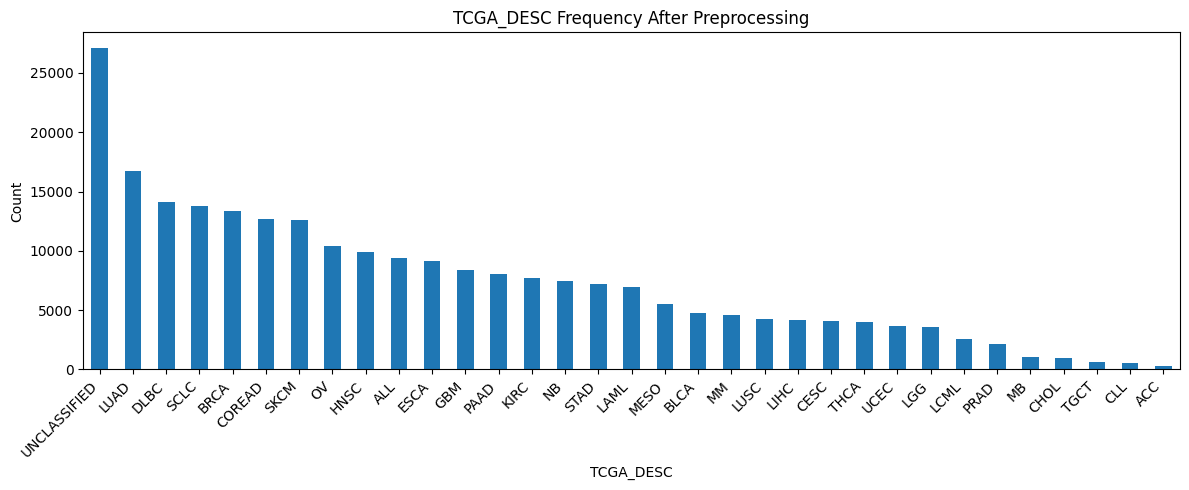

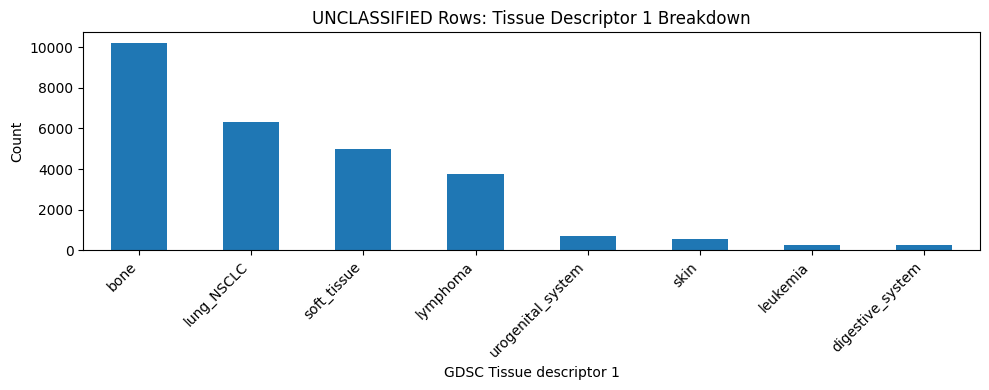

In [39]:


# ─────────────────────────────────────────────────────────────────────────────
# TCGA frequency + UNCLASSIFIED breakdown (run before Demo)
# ─────────────────────────────────────────────────────────────────────────────

TCGA_COL = 'TCGA_DESC'
DESC1_COL = 'GDSC Tissue descriptor 1'
DESC2_COL = 'GDSC Tissue descriptor 2'

# 1) Overall TCGA frequency
print("=== TCGA_DESC frequency after preprocessing ===")
tcga_freq = (
    df[TCGA_COL]
    .fillna('Missing')
    .value_counts(dropna=False)
    .rename_axis(TCGA_COL)
    .reset_index(name='Count')
)

display(tcga_freq)

# Optional percentage table too
tcga_freq_pct = (
    df[TCGA_COL]
    .fillna('Missing')
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .rename_axis(TCGA_COL)
    .reset_index(name='Percent')
)

print("\n=== TCGA_DESC percentage ===")
display(tcga_freq_pct)

# 2) UNCLASSIFIED subset
unclassified_df = df[df[TCGA_COL].astype(str).str.upper() == 'UNCLASSIFIED'].copy()

print(f"\nTotal UNCLASSIFIED rows: {len(unclassified_df):,}")

# 3) UNCLASSIFIED breakdown by Tissue Descriptor 1
print("\n=== UNCLASSIFIED breakdown by Tissue descriptor 1 ===")
unclassified_desc1 = (
    unclassified_df[DESC1_COL]
    .fillna('Missing')
    .value_counts(dropna=False)
    .rename_axis(DESC1_COL)
    .reset_index(name='Count')
)
display(unclassified_desc1)

# 4) UNCLASSIFIED breakdown by Tissue Descriptor 2
print("\n=== UNCLASSIFIED breakdown by Tissue descriptor 2 ===")
unclassified_desc2 = (
    unclassified_df[DESC2_COL]
    .fillna('Missing')
    .value_counts(dropna=False)
    .rename_axis(DESC2_COL)
    .reset_index(name='Count')
)
display(unclassified_desc2)

# 5) Combined breakdown: Descriptor 1 x Descriptor 2 inside UNCLASSIFIED
print("\n=== UNCLASSIFIED combined breakdown (Descriptor 1 × Descriptor 2) ===")
unclassified_combo = (
    unclassified_df
    .fillna({DESC1_COL: 'Missing', DESC2_COL: 'Missing'})
    .groupby([DESC1_COL, DESC2_COL])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

display(unclassified_combo)

# 6) Simple bar chart for TCGA frequency
plt.figure(figsize=(12, 5))
df[TCGA_COL].fillna('Missing').value_counts().plot(kind='bar')
plt.title('TCGA_DESC Frequency After Preprocessing')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7) Simple bar chart for UNCLASSIFIED descriptor 1 breakdown
if len(unclassified_df) > 0:
    plt.figure(figsize=(10, 4))
    unclassified_df[DESC1_COL].fillna('Missing').value_counts().plot(kind='bar')
    plt.title('UNCLASSIFIED Rows: Tissue Descriptor 1 Breakdown')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    

Demo

In [41]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [42]:
# ── Column definitions ────────────────────────────────────────────────────
cat_cols = [
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
    'CNA',
    'Gene Expression',
    'Methylation',
    'TARGET',
    'TARGET_PATHWAY',
    'DRUG_ID',
]

num_cols = [
    'tcga_was_crossfilled',
    'descriptor1_was_imputed',
    'descriptor2_was_imputed',
] + genomic_cols

feature_cols = cat_cols + num_cols

df_genomic['DRUG_ID'] = df_genomic['DRUG_ID'].astype(str)

X      = df_genomic[feature_cols].copy()
y      = df_genomic['LN_IC50'].astype(float).to_numpy()
groups = df_genomic['COSMIC_ID'].astype(str).to_numpy()

print(f"X shape : {X.shape}")
missing = [c for c in feature_cols if c not in df_genomic.columns]
print(f"Missing columns : {missing}")

X shape : (242035, 750)
Missing columns : []


In [43]:
# ── Grouped split ─────────────────────────────────────────────────────────
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test  = y[train_idx], y[test_idx]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (193535, 750)
X_test  : (48500, 750)


In [44]:
# ── Preprocessor ──────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=50,
                sparse_output=False
            ))
        ]), cat_cols),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
'''
# ── Models ────────────────────────────────────────────────────────────────
models = {
    'Ridge (baseline)': Ridge(alpha=1.0, random_state=42),

    'LightGBM (strong)': LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    'CatBoost (primary)': CatBoostRegressor(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0           # suppresses training logs
    )
}
'''

"\n# ── Models ────────────────────────────────────────────────────────────────\nmodels = {\n    'Ridge (baseline)': Ridge(alpha=1.0, random_state=42),\n\n    'LightGBM (strong)': LGBMRegressor(\n        n_estimators=200,\n        learning_rate=0.05,\n        num_leaves=63,\n        random_state=42,\n        n_jobs=-1,\n        verbosity=-1\n    ),\n\n    'CatBoost (primary)': CatBoostRegressor(\n        iterations=200,\n        learning_rate=0.05,\n        depth=6,\n        random_seed=42,\n        verbose=0           # suppresses training logs\n    )\n}\n"

In [45]:
from sklearn.linear_model import ElasticNet
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Define models ─────────────────────────────────────────────────────────
models = {
    'ElasticNet (baseline)': ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=2000,
        random_state=42
    ),
    'LightGBM (strong)': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.4,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
}

# ── Train + Evaluate standard models ─────────────────────────────────────
preds = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds[name] = pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, preds[name])))
    mae  = float(mean_absolute_error(y_test, preds[name]))
    r2   = float(r2_score(y_test, preds[name]))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

# ── Train CatBoost on raw categorical data ────────────────────────────────
cb_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0
)

cat_feature_indices = [i for i, col in enumerate(feature_cols) if col in cat_cols]

X_train_cb = X_train.copy()
X_test_cb  = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna('Unknown').astype(str)
    X_test_cb[col]  = X_test_cb[col].fillna('Unknown').astype(str)

for col in num_cols:
    X_train_cb[col] = X_train_cb[col].fillna(0)
    X_test_cb[col]  = X_test_cb[col].fillna(0)

cb_model.fit(X_train_cb, y_train, cat_features=cat_feature_indices)
cb_pred = cb_model.predict(X_test_cb)

preds['CatBoost (primary)'] = cb_pred

rmse = float(np.sqrt(mean_squared_error(y_test, cb_pred)))
mae  = float(mean_absolute_error(y_test, cb_pred))
r2   = float(r2_score(y_test, cb_pred))

print(f"\n{'='*50}")
print(f"  CatBoost (primary) — raw categorical input")
print(f"{'='*50}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")


  ElasticNet (baseline)
  RMSE : 2.0368
  MAE  : 1.6327
  R²   : 0.4581


c:\Users\shibu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



  LightGBM (strong)
  RMSE : 1.3265
  MAE  : 1.0013
  R²   : 0.7702

  CatBoost (primary) — raw categorical input
  RMSE : 1.4888
  MAE  : 1.1343
  R²   : 0.7105


In [46]:
'''

# ── Train + Evaluate ──────────────────────────────────────────────────────
for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mae  = float(mean_absolute_error(y_test, pred))
    r2   = float(r2_score(y_test, pred))

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    '''
    

'\n\n# ── Train + Evaluate ──────────────────────────────────────────────────────\nfor name, model in models.items():\n    pipe = Pipeline(steps=[(\'prep\', preprocessor), (\'model\', model)])\n    pipe.fit(X_train, y_train)\n    pred = pipe.predict(X_test)\n\n    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))\n    mae  = float(mean_absolute_error(y_test, pred))\n    r2   = float(r2_score(y_test, pred))\n\n    print(f"\n{\'=\'*50}")\n    print(f"  {name}")\n    print(f"{\'=\'*50}")\n    print(f"  RMSE : {rmse:.4f}")\n    print(f"  MAE  : {mae:.4f}")\n    print(f"  R²   : {r2:.4f}")\n    '

In [47]:
# ── Sample predictions — all three models side by side ────────────────────
n_show = 25

sample = X_test.head(n_show).copy()
sample['CELL_LINE_NAME'] = df_genomic.loc[X_test.index[:n_show], 'CELL_LINE_NAME'].values
sample['DRUG_NAME']      = df_genomic.loc[X_test.index[:n_show], 'DRUG_NAME'].values
sample['Actual_LN_IC50'] = y_test[:n_show].round(4)

# ── Add each model's predictions ──────────────────────────────────────────
sample['ElasticNet_Pred'] = preds['ElasticNet (baseline)'][:n_show].round(4)
sample['LightGBM_Pred']   = preds['LightGBM (strong)'][:n_show].round(4)
sample['CatBoost_Pred']   = preds['CatBoost (primary)'][:n_show].round(4)

# ── Interpretation based on LightGBM (best model) ────────────────────────
sample['Interpretation'] = sample['LightGBM_Pred'].apply(
    lambda x: 'Sensitive' if x < 0 else 'Resistant'
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

print(f"\n=== Sample predictions — all models (first {n_show} rows) ===")
print(sample[[
    'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME',
    'TARGET_PATHWAY', 'Actual_LN_IC50',
    'ElasticNet_Pred', 'LightGBM_Pred', 'CatBoost_Pred',
    'Interpretation'
]].to_string(index=True))


=== Sample predictions — all models (first 25 rows) ===
   CELL_LINE_NAME     TCGA_DESC     DRUG_NAME   TARGET_PATHWAY  Actual_LN_IC50  ElasticNet_Pred  LightGBM_Pred  CatBoost_Pred Interpretation
3           EW-11  UNCLASSIFIED  Camptothecin  DNA replication         -3.7420          -0.6783        -4.6638        -2.6178      Sensitive
5        COLO-829          SKCM  Camptothecin  DNA replication         -1.2350          -0.4112        -2.2557        -1.6938      Sensitive
9          TCCSUP          BLCA  Camptothecin  DNA replication         -2.3506          -0.5741        -2.1939        -1.5749      Sensitive
14        8-MG-BA           GBM  Camptothecin  DNA replication         -4.2563          -0.1804        -2.0036        -1.6317      Sensitive
18       U-118-MG           GBM  Camptothecin  DNA replication         -3.3540          -0.0649        -2.0014        -1.5066      Sensitive
20          YKG-1           GBM  Camptothecin  DNA replication         -2.7844          -0.8393  